In [1]:
import tensorflow as tf
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
import urllib.request

In [2]:
########################################################################################################################
# KREIRANJE MODELA PRETRENIRANOG NA IMAGENET SKUPU
########################################################################################################################

image_size = 260  # zavisi od učitanog modela

# Definiše poslednji konvolucioni sloj i izlazni sloj za dati model
last_conv_layer_name = 'top_conv'       # zavisi od učitanog modela
classifier_layer_name = 'predictions'   # zavisi od učitanog modela

model = tf.keras.applications.efficientnet.EfficientNetB2(include_top=True, weights='imagenet')
model.summary()

preprocess_input = tf.keras.applications.efficientnet.preprocess_input
decode_predictions = tf.keras.applications.efficientnet.decode_predictions

37432240/37432240 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 260, 260,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 260, 260,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 260, 260,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 9,177,569 (35.01 MB)

 Trainable params: 9,109,994 (34.75 MB)

 Non-trainable params: 67,575 (263.97 KB)

Image downloaded successfully!
Loaded image shape: (1440, 1440, 3)


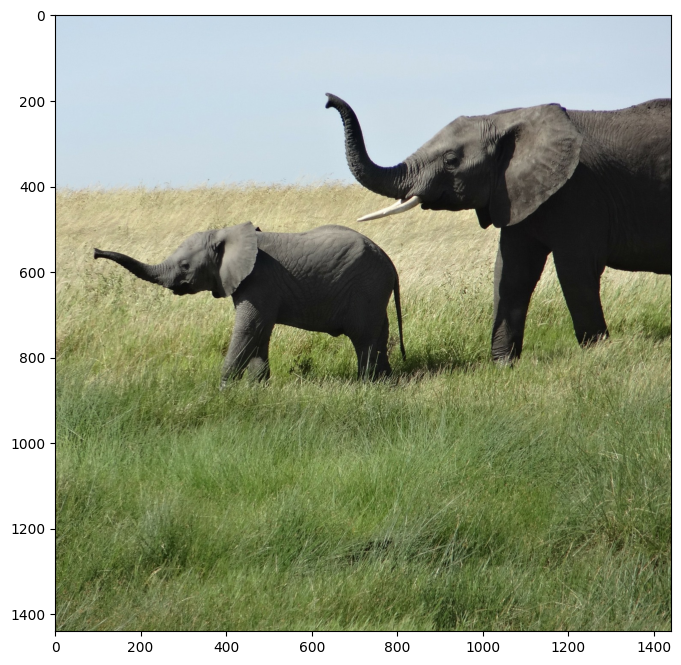

x.shape: (1, 260, 260, 3)


In [3]:
########################################################################################################################
# SKIDANJE, UČITAVANJE I PRETPROCESIRANJE SLIKE
########################################################################################################################

# Download image
url = 'https://img-datasets.s3.amazonaws.com/elephant.jpg'
img_path = os.path.join(os.getcwd(), 'elephant.jpg')
if os.path.exists(img_path):
    print(f"File already exists at {img_path}. Skipping download.")
else:
    try:
        urllib.request.urlretrieve(url, img_path)
        print("Image downloaded successfully!")
    except Exception as e:
        print(f"An error occurred: {e}")

# Read input image
img = cv.imread(img_path)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
print('Loaded image shape:', img.shape)

# Show image
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.show()

# Resize image to the model default size
x = cv.resize(img_rgb, (image_size, image_size), interpolation=cv.INTER_AREA)

# Expand dims at axis 0 to adjust shape for CNN input
x = np.expand_dims(x, axis=0)  # (image_size, image_size, 3) -> (1, image_size, image_size, 3)
print('x.shape:', x.shape)

# Preprocess image using model-default method
x = preprocess_input(x)

In [4]:
########################################################################################################################
# NALAŽENJE I PRIKAZ PREDIKCIJE MODELA
########################################################################################################################

# Get the model predictions for the image
preds = model.predict(x)
print('Top-3 predictions:')
print(decode_predictions(preds, top=3)[0])

# Get predicted class
pred_class = np.argmax(preds[0])
print('Predicted class:', pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
Top-3 predictions:
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[('n02504458', 'African_elephant', np.float32(0.8237503)), ('n01871265', 'tusker', np.float32(0.04945823)), ('n02504013', 'Indian_elephant', np.float32(0.016319988))]
Predicted class: 386


top_pred_index: tf.Tensor(386, shape=(), dtype=int32)
top_class_channel: tf.Tensor([0.82375044], shape=(1,), dtype=float32)
grads.shape: (1, 9, 9, 1408)
pooled_grads.shape: (1408,)
heatmap.shape: (9, 9)


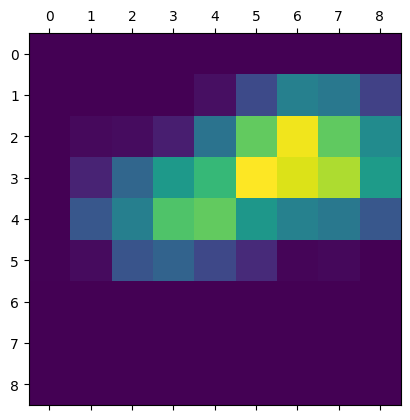

In [5]:
########################################################################################################################
# KREIRANJE HEATMAP-E KORIŠĆENJEM GRAD-CAM METODA
########################################################################################################################

# Formira model koji od slike daje aktivacije zadnjeg konvolucionog sloja
last_conv_layer = model.get_layer(last_conv_layer_name)
last_conv_layer_model = tf.keras.Model(model.inputs, last_conv_layer.output)

# Formira model koji na osnovu aktivacija zadnjeg konv. sloja daje klasifikacioni izlaz
classifier_layer = model.get_layer(classifier_layer_name)
classifier_model = tf.keras.Model(last_conv_layer.output, classifier_layer.output)

# Generišemo izlaz iz poslednjeg konvolutivnog sloja
last_conv_layer_output = last_conv_layer_model([x])

with tf.GradientTape() as tape:
    tape.watch(last_conv_layer_output)

    # Nalazimo predikcije na osnovu izlaza zadnjeg konv. sloja
    preds = classifier_model(last_conv_layer_output)

    # Nalazimo indeks prediktovane klase
    top_pred_index = tf.keras.ops.argmax(preds[0])
    print('top_pred_index:', top_pred_index)

    # Očitavamo aktivaciju koja odgovora prediktovanoj klasi
    top_class_channel = preds[:, top_pred_index]
    print('top_class_channel:', top_class_channel)

    # Računamo gradijente izdvojenog izlaza u odnosu na izlaze poslednji konv. sloj
    grads = tape.gradient(top_class_channel, last_conv_layer_output)

    # Konverzija u NumPy
    grads = tf.keras.ops.convert_to_numpy(grads)
    last_conv_layer_output = tf.keras.ops.convert_to_numpy(last_conv_layer_output)
    print('grads.shape:', grads.shape)

# Formiramo vektor čiji su elementi srednji intenziteti gradijenata za dati izlaz
# (ovaj vektor kvantifikuje značaj pojedinih izlaza konv. sloja za prediktovanu klasu)
pooled_grads = np.mean(grads, axis=(0, 1, 2))
print('pooled_grads.shape:', pooled_grads.shape)

# Množimo vrednosti izlaza zadnjeg konv. sloja određenim značajem tog izlaza
last_conv_layer_output = last_conv_layer_output[0].copy()
for i in range(pooled_grads.shape[-1]):
    last_conv_layer_output[:, :, i] *= pooled_grads[i]

# Srednja vrednost po kanalima rezultujuće feature mape predstavlja heatmap-u aktivacija klasa
heatmap = np.mean(last_conv_layer_output, axis=-1)
print('heatmap.shape:', heatmap.shape)

heatmap = np.maximum(heatmap, 0) # postavlja negativne vrednosti na 0
heatmap /= np.max(heatmap) # normalizuje vrednosti u opsegu od 0 do 1
plt.matshow(heatmap)
plt.show()

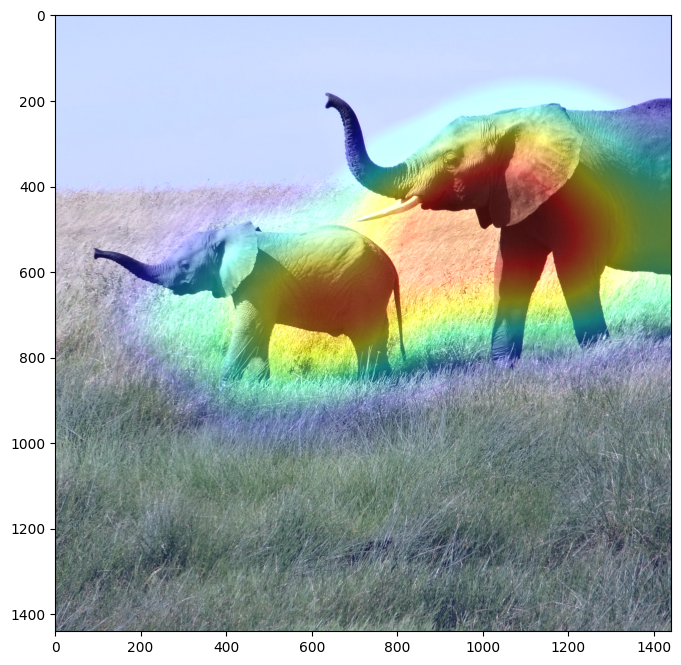

In [6]:
########################################################################################################################
# PRIKAZ HEATMAP-E PREKO ORIGINALNE SLIKE
########################################################################################################################

# Konverzija u grayscale sliku
img_heatmap = np.uint8(255 * heatmap)

# Resize heatmap-e da odgovoaraj originalnoj slici
img_heatmap = cv.resize(img_heatmap, (img.shape[1], img.shape[0]), interpolation=cv.INTER_CUBIC)

# Konverzija heatmape-e u RGB
img_heatmap = cv.applyColorMap(img_heatmap, cv.COLORMAP_JET)
img_heatmap = cv.cvtColor(img_heatmap, cv.COLOR_BGR2RGB)

# Spajanje heatmap-e sa originalnom slikom
superimposed_img = np.clip(0.4 * img_heatmap + img_rgb, 0, 255).astype(np.uint8)

# Prikaz rezultata
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.show()